# Part 3: Advanced Text Processing – LDA and BERTopic Topic Modeling
Resources:

LDA:
https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06
https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/

BERTopic:
https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly
https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html

## Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import spacy
from spacy import displacy

from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer

import pyLDAvis
import pyLDAvis.gensim_models

nlp = spacy.load("en_core_web_sm")

## Dataset

In [6]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


## 3.1 LDA 

In this section I:
- Train an LDA model on the State of the Union speeches
- Inspect the learned topics and the topic distribution for the first speech
- Train a BERTopic model
- Inspect BERTopic topics and visualize the topic distribution for the first speech

In [7]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [8]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

Code: dictionary, corpus, and LDA model

In [24]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
processed_docs_list = processed_docs.tolist()
id2word = Dictionary(processed_docs_list)
id2word.filter_extremes(no_below=5, no_above=0.5, keep_n=None)
corpus = [id2word.doc2bow(doc) for doc in processed_docs_list]

# train LDA model with 18 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=18,
    random_state=42,
    passes=10
)

Code: top 10 words for each topic

In [22]:
# print the top 10 words for each topic

print("--- LDA Topics ---")
for topic_id in range(18):
    words = lda_model.show_topic(topic_id, topn=10)
    words_str = " + ".join([f'{prob:.3f}*"{term}"' for term, prob in words])
    print(f"Topic: {topic_id}")
    print(f"Words: {words_str}\n")

--- LDA Topics ---
Topic: 0
Words: 0.000*"program" + 0.000*"today" + 0.000*"americans" + 0.000*"tonight" + 0.000*"percent" + 0.000*"budget" + 0.000*"goal" + 0.000*"thank" + 0.000*"worker" + 0.000*"investment"

Topic: 1
Words: 0.004*"spain" + 0.004*"article" + 0.004*"minister" + 0.004*"british" + 0.003*"convention" + 0.003*"indians" + 0.003*"tribe" + 0.003*"port" + 0.003*"france" + 0.003*"indian"

Topic: 2
Words: 0.055*"communist" + 0.037*"soviet" + 0.020*"atomic" + 0.019*"aggression" + 0.017*"korea" + 0.013*"ally" + 0.011*"ruler" + 0.010*"threat" + 0.009*"nations" + 0.009*"weapon"

Topic: 3
Words: 0.009*"cent" + 0.008*"june" + 0.007*"gold" + 0.006*"island" + 0.006*"silver" + 0.006*"bond" + 0.005*"tariff" + 0.005*"method" + 0.005*"pension" + 0.004*"cuba"

Topic: 4
Words: 0.034*"program" + 0.016*"soviet" + 0.013*"major" + 0.012*"inflation" + 0.012*"area" + 0.010*"nuclear" + 0.009*"goal" + 0.008*"percent" + 0.008*"1980" + 0.007*"u.s."

Topic: 5
Words: 0.057*"mexico" + 0.024*"texas" + 0.02

Code: topic distribution for the first speech

In [23]:
# print the topic distribution for the first speech

first_doc_topics = lda_model.get_document_topics(corpus[0])
sorted(first_doc_topics, key=lambda x: -x[1])

[(11, np.float32(0.8448292)),
 (14, np.float32(0.054299716)),
 (3, np.float32(0.047270834)),
 (1, np.float32(0.034212563)),
 (7, np.float32(0.013462779))]

Code: LDA visualization with pyLDAvis

In [12]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(
    lda_model,
    corpus,
    id2word
)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.138201  0.185135       1        1  37.400542
3      0.039980  0.215045       2        1  16.002495
7      0.034398  0.142522       3        1  14.374112
14    -0.265977 -0.051565       4        1  10.777706
12    -0.016435  0.119199       5        1   6.115119
8     -0.204426  0.109154       6        1   5.211799
11    -0.245395 -0.054064       7        1   4.075065
4     -0.280700 -0.041461       8        1   3.470452
5      0.058330  0.229449       9        1   2.345088
2      0.037810 -0.165413      10        1   0.221367
0      0.088025 -0.085999      11        1   0.000810
16     0.088020 -0.086000      12        1   0.000782
10     0.088026 -0.086000      13        1   0.000778
6      0.088031 -0.086001      14        1   0.000777
13     0.088030 -0.086001      15        1   0.000777
17     0.088028 -0.086000      16        1   0.000777
9      0.088026 -0.086000      17        1   0.000777
15     0.088027 -0.086000      18        1   0.000777, topic_info=            Term         Freq        Total Category  logprob  loglift
978       mexico   829.000000   829.000000  Default  30.0000  30.0000
509      program  1252.000000  1252.000000  Default  29.0000  29.0000
31     americans   996.000000   996.000000  Default  28.0000  28.0000
3190     british   629.000000   629.000000  Default  27.0000  27.0000
666      tonight   658.000000   658.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
306      housing     0.000379   220.258689  Topic18  -8.8757  -1.5082
339   investment     0.000379   361.872452  Topic18  -8.8757  -2.0047
60         basic     0.000379   226.053013  Topic18  -8.8757  -1.5342
650   technology     0.000379   197.858828  Topic18  -8.8757  -1.4009
330    insurance     0.000379   253.468628  Topic18  -8.8757  -1.6486

[1228 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
4105      3  0.976861   17th
5579      9  0.989664   1815
4106      3  0.982089   1823
4933      2  0.970401   1865
5183      5  0.976028   1901
...     ...       ...    ...
744       3  0.110288  young
744       4  0.529381  young
744       5  0.022058  young
744       7  0.154403  young
744       8  0.022058  young

[2091 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 8, 15, 13, 9, 12, 5, 6, 3, 1, 17, 11, 7, 14, 18, 10, 16])

## 3.2 BERTopic modeling

Next, I fit a BERTopic model with a minimum topic size of 3, remove
stopwords from the topic representations using a `CountVectorizer`, and inspect
the topics and their probabilities for the first speech.

Code: BERTopic fit and stopword cleanup

In [15]:
docs = sou['Text'].to_list()

# train the model - this takes about 30 seconds
# remove stop words from the topics

topic_model = BERTopic(
    min_topic_size=3,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

vectorizer_model = CountVectorizer(stop_words="english")
topic_model.update_topics(
    docs,
    vectorizer_model=vectorizer_model
)

2025-11-21 06:19:49,654 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]
2025-11-21 06:19:59,341 - BERTopic - Embedding - Completed ✓
2025-11-21 06:19:59,342 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 06:20:09,491 - BERTopic - Dimensionality - Completed ✓
2025-11-21 06:20:09,492 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 06:20:09,512 - BERTopic - Cluster - Completed ✓
2025-11-21 06:20:09,516 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 06:20:10,973 - BERTopic - Representation - Completed ✓


Code: topic info table

In [17]:
# output the top 10 words for each topic
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,75,-1_government_states_united_congress,"[government, states, united, congress, year, p...",[\nJump toPart II |Part III\nPart 1. [On Our F...
1,0,31,0_world_people_new_years,"[world, people, new, years, year, american, am...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,18,1_states_government_united_public,"[states, government, united, public, congress,...",[\nFellow-Citizens of the Senate and House of ...
3,2,13,2_states_government_public_united,"[states, government, public, united, congress,...",[\nFellow Citizens of the Senate and of the Ho...
4,3,11,3_america_american_americans_people,"[america, american, americans, people, tonight...","[\nThe President. Madam Speaker, Mr. Vice Pres..."
5,4,11,4_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...","[\nMr. President, Mr. Speaker, Members of the ..."
6,5,11,5_america_new_people_americans,"[america, new, people, americans, years, jobs,...","[\nMadam Speaker, Mr. Vice President, Members ..."
7,6,10,6_states_government_united_congress,"[states, government, united, congress, country...",[\nFellow-Citizens of the Senate and of the Ho...
8,7,10,7_states_united_war_british,"[states, united, war, british, great, citizens...",[\nThe Senate and House of Representatives of ...
9,8,10,8_government_work_great_public,"[government, work, great, public, law, congres...",[\nTo the Senate and House of Representatives:...


Code: topic probability distribution for the first speech

100%|██████████| 1/1 [00:15<00:00, 15.39s/it]


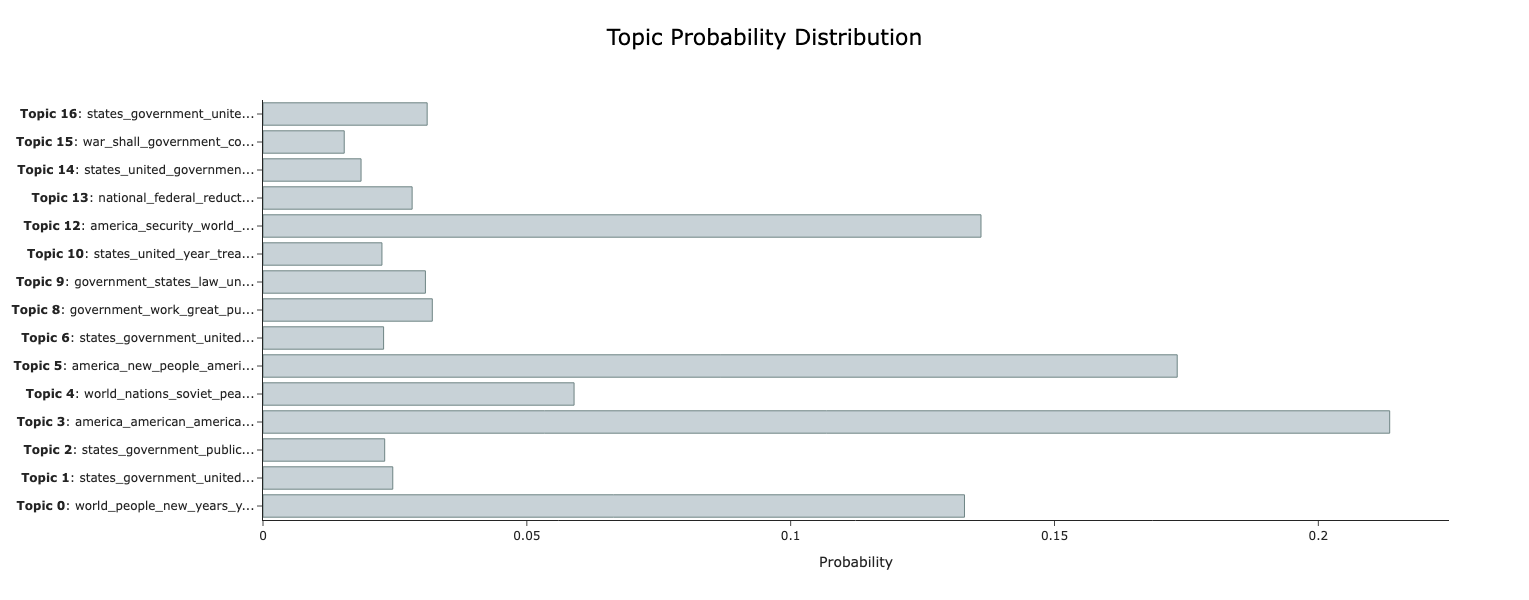

In [18]:
# output the topic distribution for the first speech

topic_distr, _ = topic_model.approximate_distribution(docs)
first_distribution = topic_distr[0] 
fig = topic_model.visualize_distribution(first_distribution,
                                         title="Topic Probability Distribution")
fig.show()

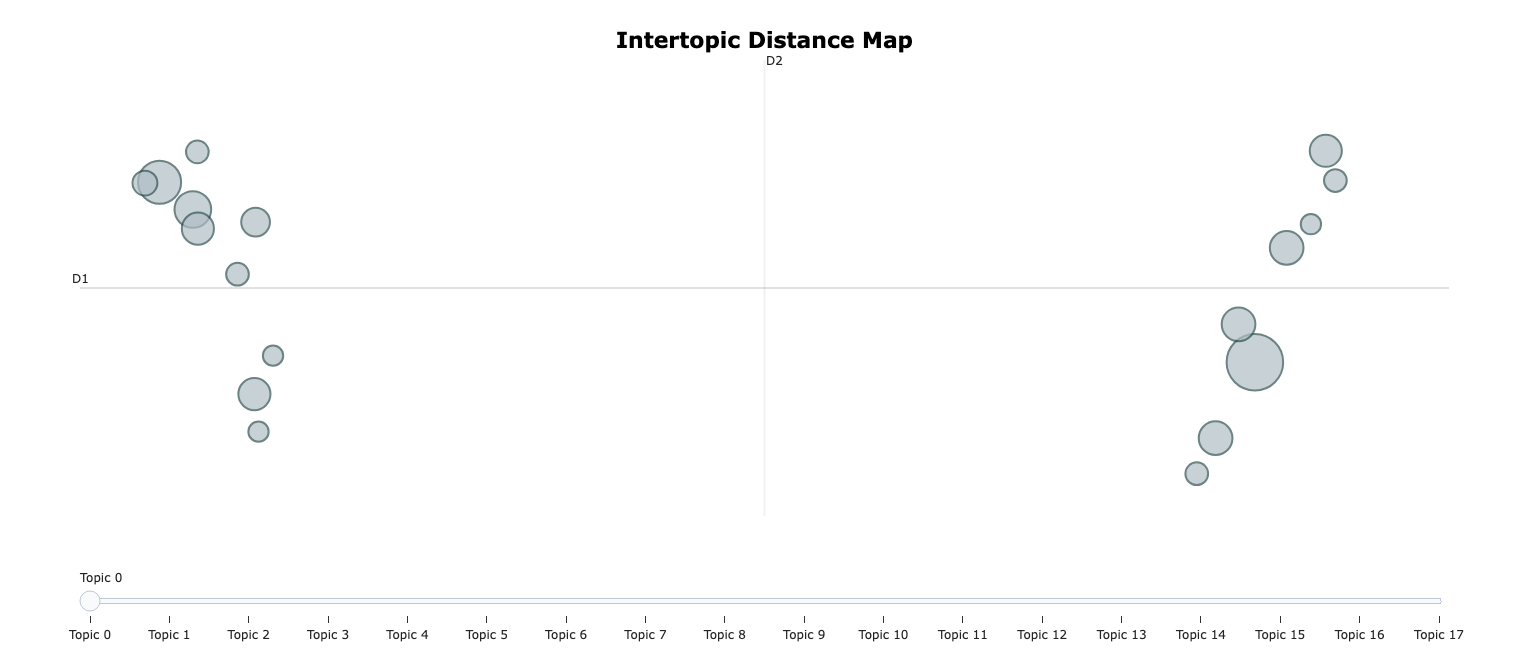

In [19]:
# run this cell to visualize the topics
topic_model.visualize_topics()